In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

sns.set(style="whitegrid")
df = pd.read_csv("facebook_ads_data.csv")
df.head()


,ad_date,campaign_name,total_spend,total_impressions,total_clicks,total_value,cpc,cpm,ctr,romi
0,2022-11-05,Expansion,0.00,0,0,0.00,NaN,NaN,NaN,NaN
1,2022-11-01,Expansion,0.00,0,0,0.00,NaN,NaN,NaN,NaN
2,2022-10-31,Expansion,227.45,6054,58,191.87,3.92,37.57,0.009580,0.843570
3,2022-10-30,Expansion,335.91,27562,69,472.61,4.87,12.19,0.002503,1.406954
4,2022-10-29,Expansion,714.03,33358,115,680.34,6.21,21.41,0.003447,0.952817


In [2]:
df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1494 entries, 0 to 1493
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ad_date            1494 non-null   object 
 1   campaign_name      1494 non-null   object 
 2   total_spend        1494 non-null   float64
 3   total_impressions  1494 non-null   int64  
 4   total_clicks       1494 non-null   int64  
 5   total_value        1494 non-null   float64
 6   cpc                1443 non-null   float64
 7   cpm                1462 non-null   float64
 8   ctr                1462 non-null   float64
 9   romi               1462 non-null   float64
dtypes: float64(6), int64(2), object(2)
memory usage: 116.8+ KB


Index(['ad_date', 'campaign_name', 'total_spend', 'total_impressions',
       'total_clicks', 'total_value', 'cpc', 'cpm', 'ctr', 'romi'],
      dtype='object')

In [3]:
df['ad_date'] = pd.to_datetime(df['ad_date'])
df = df.sort_values('ad_date')

df_2021 = df[(df['ad_date'] >= '2021-01-01') & 
             (df['ad_date'] <= '2021-12-31')]

daily_data = df_2021.groupby('ad_date').agg({
    'total_spend': 'sum',
    'total_value': 'sum'
}).reset_index()

daily_data = daily_data.sort_values('ad_date')
print(daily_data.head())


     ad_date  total_spend  total_value
0 2021-01-01         0.39         0.59
1 2021-01-02         7.74         6.90
2 2021-01-04        70.06        68.47
3 2021-01-05        81.15        61.68
4 2021-01-06       142.77       145.97


#Графік з щоденною сумою витрат на рекламу у 2021 році

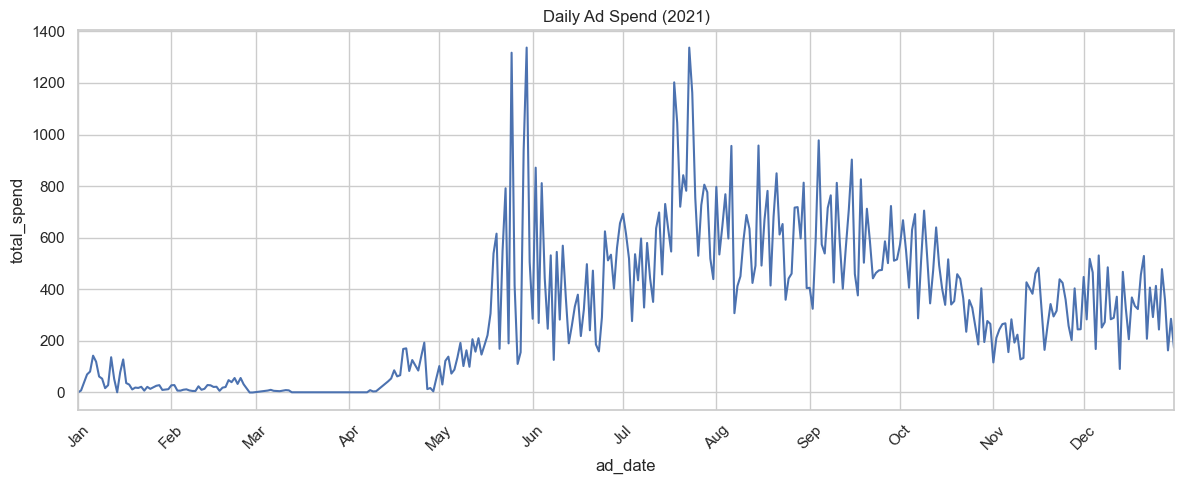

In [4]:
plt.figure(figsize=(12,5))

sns.lineplot(data=daily_data, x='ad_date', y='total_spend')

plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))

plt.xticks(rotation=45)
plt.margins(x=0)

plt.title("Daily Ad Spend (2021)")
plt.tight_layout()
plt.show()

Графік з щоденним ROMI у 2021 році

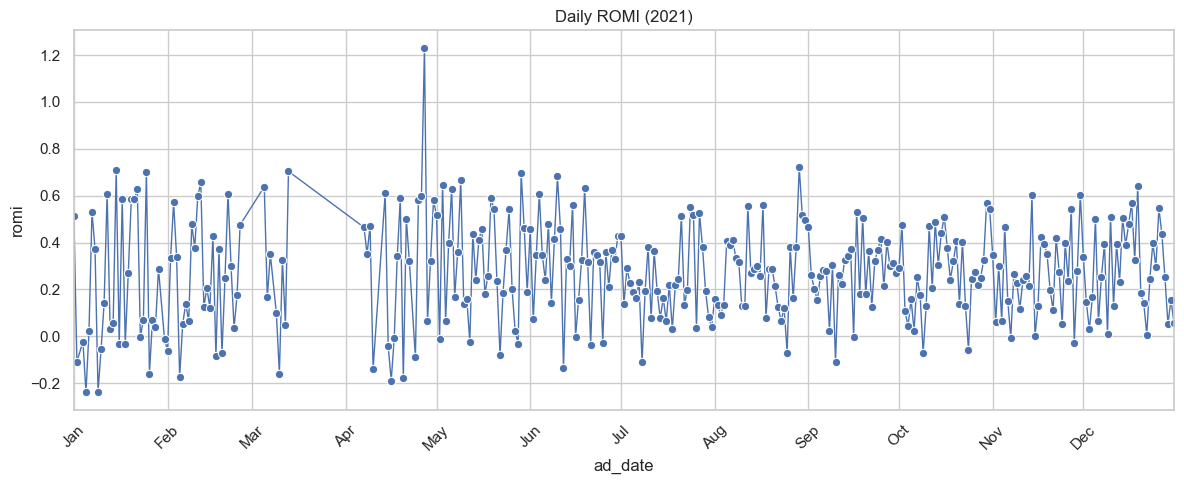

True


In [5]:
daily_data['romi'] = (
    (daily_data['total_value'] - daily_data['total_spend']) /
    daily_data['total_spend'])
plt.figure(figsize=(12,5))

sns.lineplot(
    data=daily_data,
    x='ad_date',
    y='romi',
    marker='o',
    linewidth=1
)

plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))

plt.xticks(rotation=45)
plt.margins(x=0)

plt.title("Daily ROMI (2021)")
plt.tight_layout()
plt.show()
daily_data[
    (daily_data['ad_date'] >= '2021-03-01') &
    (daily_data['ad_date'] <= '2021-04-30')
].sort_values('romi', ascending=False)
print(daily_data['ad_date'].is_monotonic_increasing)

In [6]:
daily_data['spend_roll'] = daily_data['total_spend'].rolling(7, min_periods=1).mean()
daily_data['romi_roll'] = daily_data['romi'].rolling(7, min_periods=1).mean()
daily_data[['ad_date', 'total_spend', 'spend_roll']].head(10)

,ad_date,total_spend,spend_roll
0,2021-01-01,0.39,0.390000
1,2021-01-02,7.74,4.065000
2,2021-01-04,70.06,26.063333
3,2021-01-05,81.15,39.835000
4,2021-01-06,142.77,60.422000
5,2021-01-07,119.42,70.255000
6,2021-01-08,61.97,69.071429
7,2021-01-09,53.63,76.677143
8,2021-01-10,16.80,77.971429
9,2021-01-11,28.46,72.028571


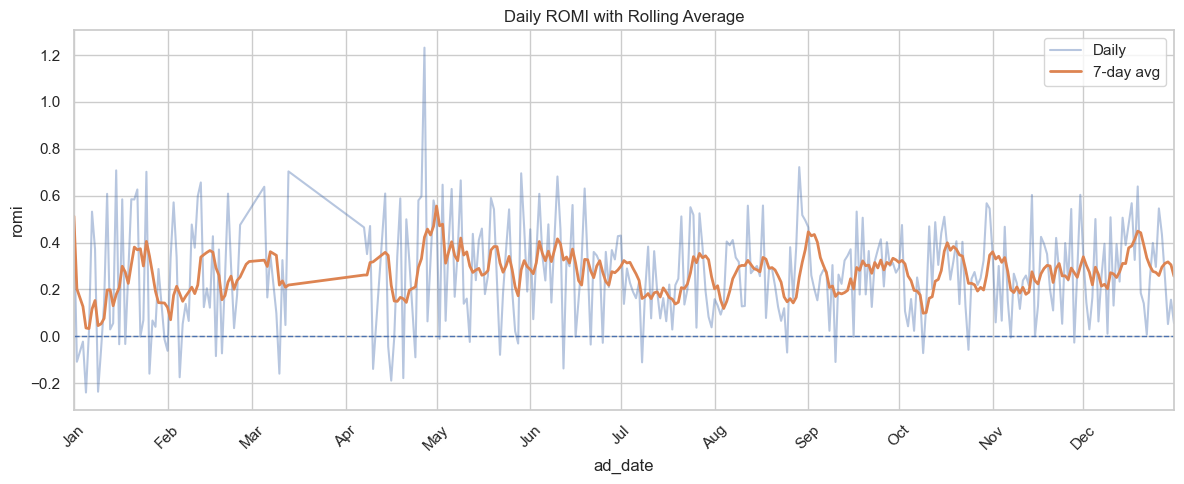

In [7]:
plt.figure(figsize=(12,5))

sns.lineplot(data=daily_data, x='ad_date', y='romi', label='Daily', alpha=0.4)
sns.lineplot(data=daily_data, x='ad_date', y='romi_roll', label='7-day avg', linewidth=2)

plt.axhline(0, linestyle='--', linewidth=1)

plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))

plt.xticks(rotation=45)
plt.margins(x=0)

plt.title("Daily ROMI with Rolling Average")
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
campaign_data = df.groupby('campaign_name').agg({
    'total_spend': 'sum',
    'total_value': 'sum'
}).reset_index()
campaign_data


,campaign_name,total_spend,total_value
0,Brand,539.92,670.15
1,Crazy discounts,2175.29,2583.59
2,Discounts,2856.39,3516.27
3,Electronics,23920.42,29169.38
4,Expansion,67212.82,83288.66
5,Hobbies,11326.97,13974.63
6,Lookalike,63631.09,80234.70
7,New items,2936.97,3742.05
8,Promos,4993.84,8793.77
9,Trendy,1992.31,3798.90


In [9]:
campaign_data = df.groupby('campaign_name').agg({
    'total_spend': 'sum',
    'total_value': 'sum'
}).reset_index()

campaign_data['romi'] = (
    (campaign_data['total_value'] - campaign_data['total_spend']) 
    / campaign_data['total_spend']
)
campaign_data[['campaign_name', 'total_spend', 'total_value', 'romi']]

,campaign_name,total_spend,total_value,romi
0,Brand,539.92,670.15,0.241202
1,Crazy discounts,2175.29,2583.59,0.187699
2,Discounts,2856.39,3516.27,0.231019
3,Electronics,23920.42,29169.38,0.219434
4,Expansion,67212.82,83288.66,0.239178
5,Hobbies,11326.97,13974.63,0.233748
6,Lookalike,63631.09,80234.70,0.260935
7,New items,2936.97,3742.05,0.274119
8,Promos,4993.84,8793.77,0.760923
9,Trendy,1992.31,3798.90,0.906782


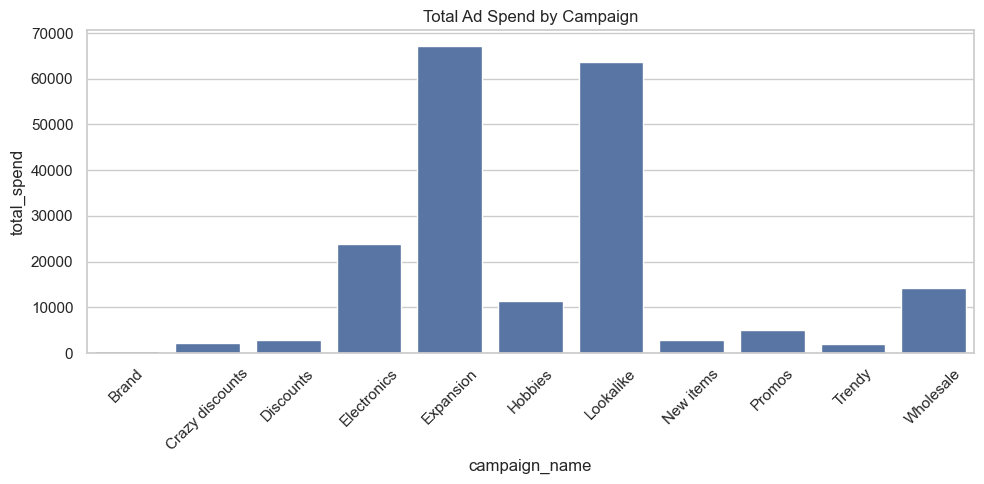

In [10]:
plt.figure(figsize=(10,5))

sns.barplot(data=campaign_data, x='campaign_name', y='total_spend')

plt.xticks(rotation=45)
plt.title("Total Ad Spend by Campaign")
plt.tight_layout()
plt.show()

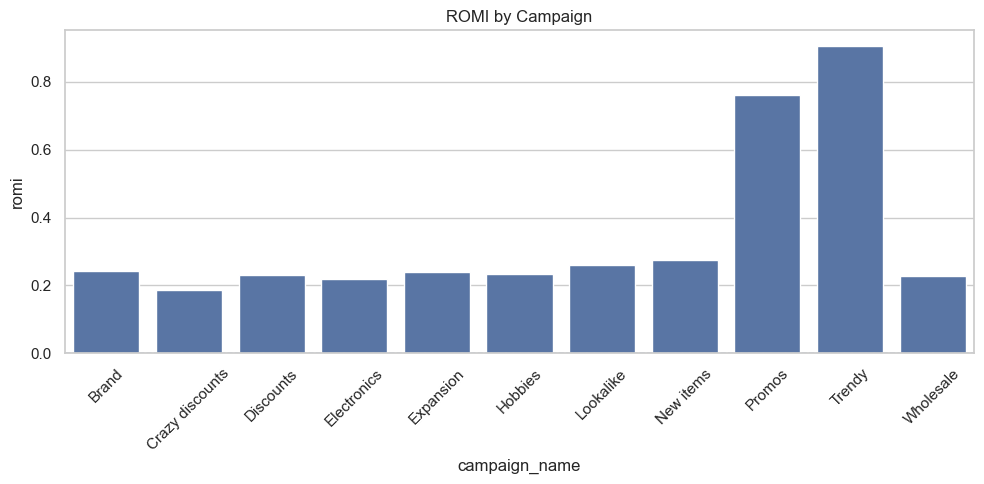

In [11]:
plt.figure(figsize=(10,5))

sns.barplot(data=campaign_data, x='campaign_name', y='romi')

plt.axhline(0, linestyle='--', linewidth=1)

plt.xticks(rotation=45)
plt.title("ROMI by Campaign")

plt.tight_layout()
plt.show()

In [12]:
df['romi'] = (df['total_value'] - df['total_spend']) / df['total_spend']


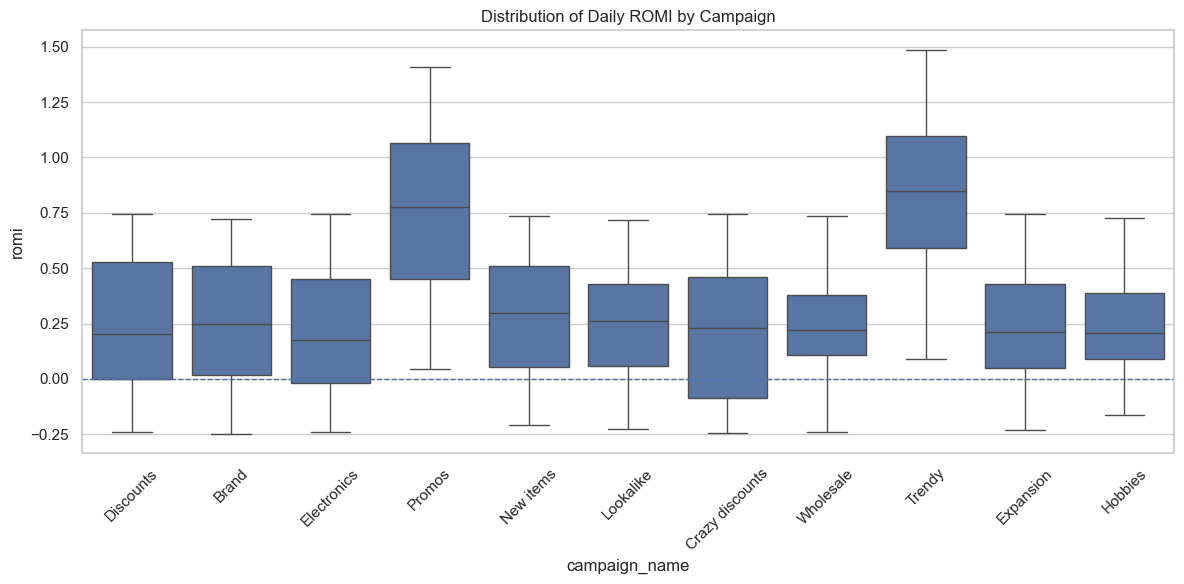

In [13]:
plt.figure(figsize=(12,6))

sns.boxplot(data=df, x='campaign_name', y='romi')

plt.axhline(0, linestyle='--', linewidth=1)

plt.xticks(rotation=45)
plt.title("Distribution of Daily ROMI by Campaign")

plt.tight_layout()
plt.show()

In [14]:
df['romi'] = (df['total_value'] - df['total_spend']) / df['total_spend']
df['romi'].describe()

count    1462.000000
mean        0.326322
std         0.343012
min        -0.248555
25%         0.067832
50%         0.299482
75%         0.527423
max         1.486911
Name: romi, dtype: float64

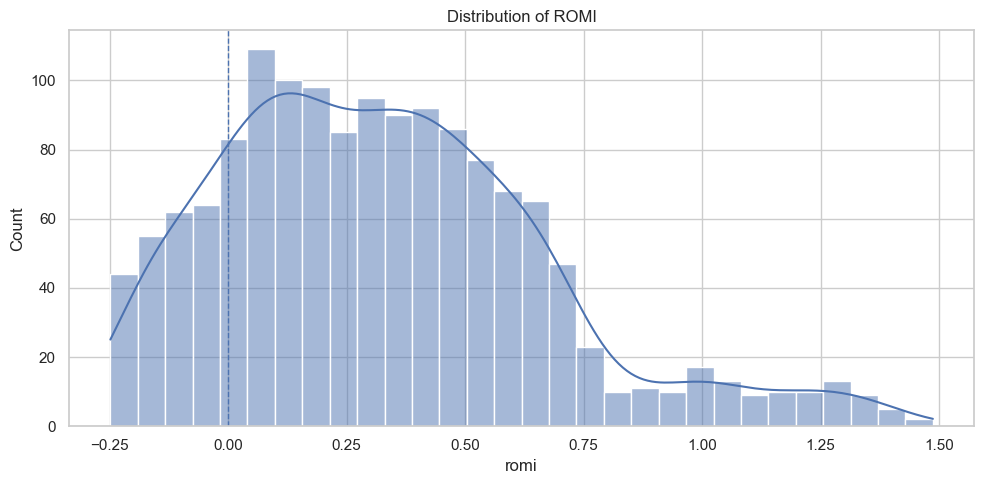

In [15]:
plt.figure(figsize=(10,5))

sns.histplot(df['romi'], bins=30, kde=True)

plt.axvline(0, linestyle='--', linewidth=1)

plt.title("Distribution of ROMI")
plt.xlabel("romi")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

In [16]:
corr = df.corr(numeric_only=True)
corr

,total_spend,total_impressions,total_clicks,total_value,cpc,cpm,ctr,romi
total_spend,1.000000,0.475607,0.480066,0.978890,0.262254,0.482027,-0.025495,-0.114859
total_impressions,0.475607,1.000000,0.765489,0.472037,-0.093097,-0.121094,-0.155701,-0.099520
total_clicks,0.480066,0.765489,1.000000,0.472124,-0.159521,-0.032829,0.200440,-0.101495
total_value,0.978890,0.472037,0.472124,1.000000,0.250851,0.471338,-0.022267,-0.013733
cpc,0.262254,-0.093097,-0.159521,0.250851,1.000000,0.593732,-0.210719,-0.076911
cpm,0.482027,-0.121094,-0.032829,0.471338,0.593732,1.000000,0.116213,-0.062676
ctr,-0.025495,-0.155701,0.200440,-0.022267,-0.210719,0.116213,1.000000,-0.049992
romi,-0.114859,-0.099520,-0.101495,-0.013733,-0.076911,-0.062676,-0.049992,1.000000


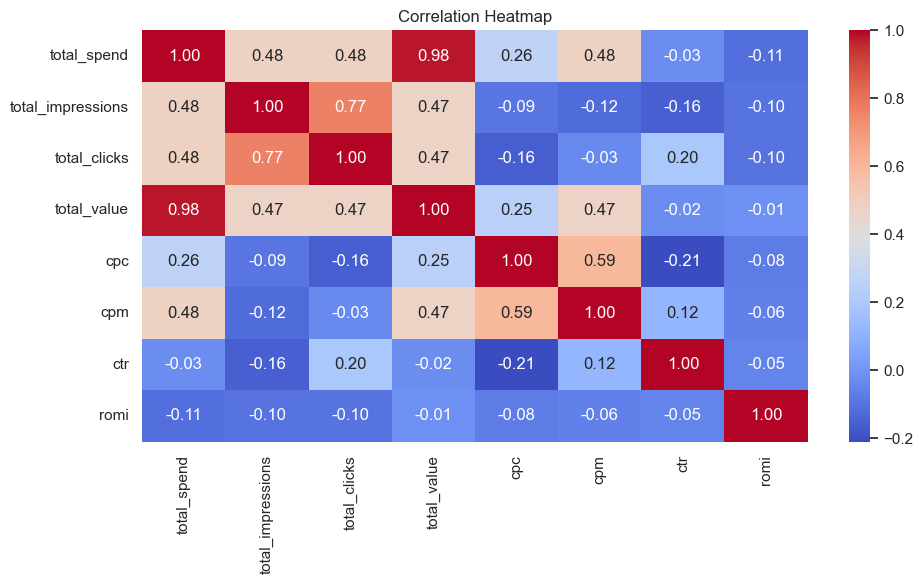

Index(['ad_date', 'campaign_name', 'total_spend', 'total_impressions',
       'total_clicks', 'total_value', 'cpc', 'cpm', 'ctr', 'romi'],
      dtype='object')

In [17]:
plt.figure(figsize=(10,6))

corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()
df.columns

In [18]:
corr_matrix = corr.copy()

np.fill_diagonal(corr_matrix.values, np.nan)

max_corr = corr_matrix.unstack().idxmax()
max_value = corr_matrix.unstack().max()

min_corr = corr_matrix.unstack().idxmin()
min_value = corr_matrix.unstack().min()





In [19]:
round(max_value, 2), max_corr

(0.98, ('total_spend', 'total_value'))

In [20]:
round(min_value, 2), min_corr

(-0.21, ('cpc', 'ctr'))

In [21]:
corr['total_value'].sort_values(ascending=False)

total_value          1.000000
total_spend          0.978890
total_clicks         0.472124
total_impressions    0.472037
cpm                  0.471338
cpc                  0.250851
romi                -0.013733
ctr                 -0.022267
Name: total_value, dtype: float64

Теплова карта кореляції показує, що найвищу кореляцію (≈ 0.98) мають показники total_spend та total_value. Це свідчить про сильний позитивний зв’язок між витратами на рекламу та отриманим доходом.
Найнижча кореляція (≈ -0.21) спостерігається між показниками cpc та ctr, що вказує на слабкий зворотний зв’язок між ними.
Показник total_value найбільше корелює з total_spend, а також має помірний зв’язок з total_impressions, total_clicks та cpm.

In [22]:
df[['total_spend', 'total_value']].describe()

,total_spend,total_value
count,1494.000000,1494.000000
mean,131.035964,165.457450
std,214.968986,274.764573
min,0.000000,0.000000
25%,18.047500,24.350000
50%,48.515000,65.460000
75%,161.790000,196.595000
max,2035.490000,2562.600000


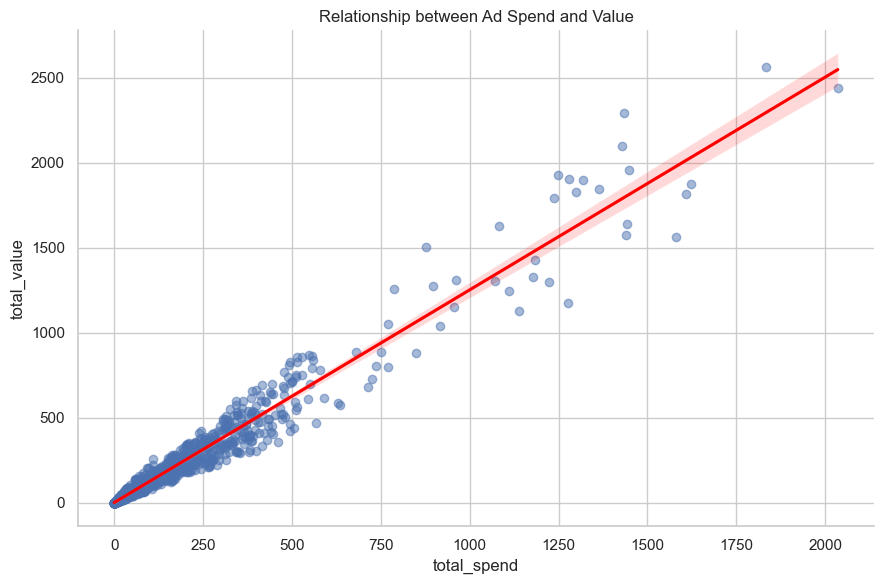

In [23]:
sns.lmplot(
    data=df,
    x='total_spend',
    y='total_value',
    height=6,
    aspect=1.5,
    scatter_kws={'alpha': 0.5},
    line_kws={'color': 'red'}
)

plt.title("Relationship between Ad Spend and Value")
plt.tight_layout()
plt.show()

Точкова діаграма з лінійною регресією показує сильний позитивний зв’язок між total_spend та total_value. Зі збільшенням витрат на рекламу зростає і отриманий дохід. Точки розташовані близько до лінії регресії, що підтверджує високу кореляцію між цими показниками.